SAMAGRA GUPTA 590014891 AIML B12

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


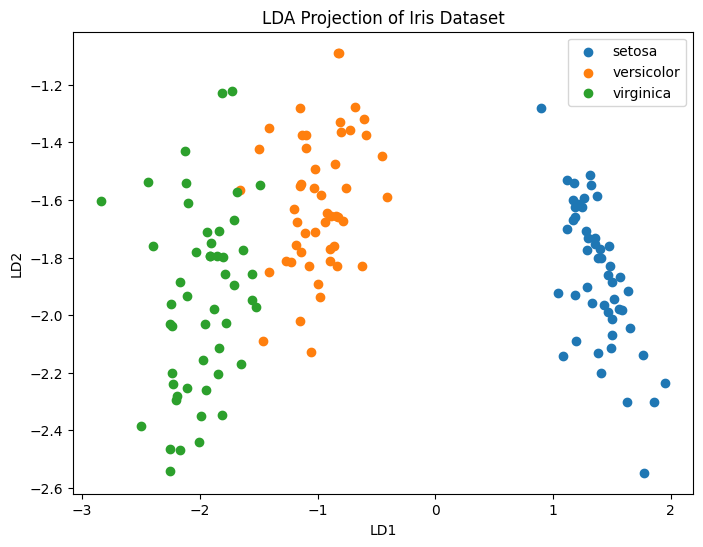

In [ ]:
import numpy as np                                                            # Name : Aruansh Khare | SAP ID: 590012991 | Batch 11
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Number of features
n_features = X.shape[1]

# Get class labels
class_labels = np.unique(y)

# Step 1: Compute overall mean
mean_overall = np.mean(X, axis=0)

# Step 2: Compute SW (Within class scatter matrix)
SW = np.zeros((n_features, n_features))

for c in class_labels:
    X_c = X[y == c]
    mean_c = np.mean(X_c, axis=0)

    for x in X_c:
        x = x.reshape(n_features,1)
        mean_c = mean_c.reshape(n_features,1)
        SW += (x - mean_c).dot((x - mean_c).T)

# Step 3: Compute SB (Between class scatter matrix)
SB = np.zeros((n_features, n_features))

for c in class_labels:
    X_c = X[y == c]
    n_c = X_c.shape[0]
    mean_c = np.mean(X_c, axis=0).reshape(n_features,1)
    mean_overall_r = mean_overall.reshape(n_features,1)

    SB += n_c * (mean_c - mean_overall_r).dot((mean_c - mean_overall_r).T)

# Step 4: Solve eigenvalue problem
A = np.linalg.inv(SW).dot(SB)

eigenvalues, eigenvectors = np.linalg.eig(A)

# Step 5: Sort eigenvectors
idx = np.argsort(abs(eigenvalues))[::-1]
eigenvectors = eigenvectors[:, idx]

# Step 6: Select top 2 eigenvectors
W = eigenvectors[:, :2]

# Step 7: Project data
X_lda = X.dot(W)

# Step 8: Plot
plt.figure(figsize=(8,6))

for label in class_labels:
    plt.scatter(
        X_lda[y == label, 0],
        X_lda[y == label, 1],
        label=iris.target_names[label]
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Projection of Iris Dataset")
plt.legend()
plt.show()